In [3]:
import numpy as np
import random
from functools import reduce
from itertools import chain, combinations, product, repeat
from scipy import linalg, sparse
import matplotlib.pyplot as plt
import os
from scipy.stats import unitary_group
from toqito.channels import partial_trace

In [4]:
# Gates:

Id2 = np.array([[1,0],[0,1]], dtype = 'complex128')
S_X = np.array([[0,1],[1,0]], dtype = 'complex128')
S_Y = np.array([[0,-1j],[1j,0]], dtype = 'complex128')
S_Z = np.array([[1,0],[0,-1]], dtype = 'complex128')
paulis = [Id2, S_X, S_Y, S_Z]/np.sqrt(2)
basis4by4=np.kron(paulis,paulis)

"""
bt2btSwap = np.array([[1,0,0,0],[0,0,1,0],[0,1,0,0],[0,0,0,1]])#, dtype = "complex128")
bt2trtSwap = np.zeros([6,6])
nonZeroList=[(0,0),(1,3),(2,1),(3,4),(4,2),(5,5)]
for i in nonZeroList:
    bt2trtSwap[i] = 1

trt2btSwap = bt2trtSwap.T

def reduceTensorProd(iterable, initializer=None):
    it = iter(iterable)
    if initializer is None:
        value = next(it)
    else:
        value = initializer
    for element in it:
        value = np.tensordot(value, element,[[],[]])
    return value
"""

x=unitary_group.rvs(3)

def inner(X,Y):
    if type(X)!=np.ndarray:
        X=X.toarray()
        Y=Y.toarray()
    prod=np.trace(X.T.conj()@Y)
    return prod
    
# uniform-U(4) matrices:
# checked that the eigenvalue distribution is uniform
def mkU(n):
    Un = (np.random.random([n,n]) + 1j* np.random.random([n,n]))/np.sqrt(2)
    q,r = linalg.qr(Un)
    #d = np.diag(r)
    #ph = d/abs(d)
    #q = q * ph * q   
    return q

"""eigVals=np.array([0])
for i in range(100):
    [evals,evecs]=linalg.eig(mkU(100))
    eigVals = np.concatenate([eigVals,evals])
plt.hist(np.arctan(np.real(eigVals[1:])/np.imag(eigVals[1:])),20)"""


def mkLiouvillian(rate, dt, ldbldOp=S_Z): 
    # Not sure how to include an environment qutrit and maintain unitarity

    L1 = np.kron(np.sqrt(rate/2) *ldbldOp, np.eye(2))
    L2 = np.kron(np.eye(2), np.sqrt(rate/2) *ldbldOp)
    
    h = -1j * linalg.logm(unitary_group.rvs(4)) #- (np.kron(ldbldOp, np.eye(2)) + np.kron(np.eye(2), ldbldOp))
    
    H =  (np.kron(h.conj(), np.eye(4)) - np.kron(np.eye(4), h) )
    
    #print(np.allclose(H, H.T.conj()))
    lindblads = [L1,L2]
    
    G = np.zeros([len(L1)**2,len(L1)**2], dtype = 'complex128')
    for L in lindblads:
        G += np.kron(L.conj(), L) - 1/2 * np.kron(np.eye(len(L)), L.T.conj()@L) - 1/2 * np.kron(L.T@L.conj(), np.eye(len(L)))
        
    # print(np.allclose(G, G.T.conj()) )
    denseU=linalg.expm( (-1j*H + G) * dt)
    
    return denseU # to act on the vectorized density matrix of 2 qubits

def mkKrausOps(U): 
    X = np.reshape(np.transpose(np.reshape(U,[4]*int(np.log2(len(U)))),[3,1,2,0]),list(U.shape))   
    [eigVal, eigVecs] = linalg.eig(X)
    
    krausOps=[]
    
    for i in range(len(U)):
        if abs(eigVal[i])>1e-7:
            krausOps = krausOps + [ sparse.bsr_matrix(np.sqrt(eigVal[i]) * np.reshape(eigVecs[:,i],[4,4]))]
            
    return krausOps


def decompKrausOps(krausOps):
    # for each kraus operator, there is a set of k_abs that
    # stores the inner product of each on-site kraus ops with the basis in a row
    
    k_abs=np.array([[] for i in range(16)],dtype='complex128').T
    for (k,op) in enumerate(krausOps):
        k_temp = np.zeros(len(basis4by4),dtype='complex128')
        for (i,b) in enumerate(basis4by4):
            k_temp[i] = inner(b, op)
        k_abs = np.vstack([k_abs,k_temp])
        
    return k_abs


In [6]:
mkKrausOps(U)

array([[-0.12807614-0.10169799j,  0.11360663-0.06513421j,
        -0.06838804+0.08617775j, ...,  0.1049712 -0.02327876j,
         0.10363481-0.12260119j,  0.03343994+0.1936833j ],
       [-0.12019487-0.11219104j, -0.12136963+0.13457957j,
         0.08433526+0.12027975j, ...,  0.18520356-0.00629697j,
        -0.01791101+0.03338702j, -0.11501458-0.07054574j],
       [-0.09695855-0.06254504j, -0.15970897-0.07767034j,
        -0.19037328+0.00529297j, ...,  0.10645529+0.08237128j,
         0.11720797-0.0971179j , -0.07742807-0.16808866j],
       ...,
       [-0.06353871-0.07763037j, -0.0530216 -0.02195553j,
         0.02120407-0.02906077j, ..., -0.10883432-0.04164951j,
         0.0442092 -0.08484891j,  0.14095691-0.01761802j],
       [-0.09076719-0.16004105j, -0.03490528-0.02370684j,
         0.08196533-0.12072725j, ...,  0.14401895-0.03343607j,
         0.16472988+0.09091264j, -0.01453822+0.04270092j],
       [-0.0671054 -0.06183399j,  0.04039553+0.00642322j,
         0.02646432+0.16904085

True


/Users/cathy/anaconda3/lib/python3.7/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/Users/cathy/anaconda3/lib/python3.7/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


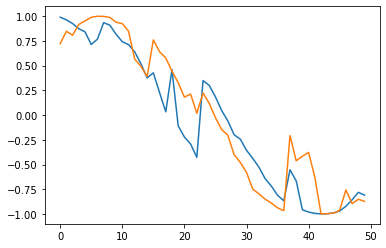

In [5]:
# check if qr decomp gives the same random unitary:
u1 = mkU(50)
[eigVals1,eigVecs1] = linalg.eig(u1)
u2 = unitary_group.rvs(50)
print(np.allclose(u2@u2.T.conj(), np.eye(50)))
[eigVals2,eigVecs2] = linalg.eig(u2)

plt.figure()
plt.plot(eigVals1)
plt.plot(eigVals2)

In [5]:
# at layers where PBC is not needed
def mkGlobalKrausOps(layer, Nqubit, rate, dt):
    
    allKs = {}

    if np.mod(layer,2) == 0:    
        # position records the site with the non-trivial unitary
        
        positions = range(0, Nqubit-1, 2)
        
        #krausOps={}
        for pos in positions:
            
            # one needs to make N/2 different random unitaries
        
            #krausOps[pos] = mkKrausOps(mkLiouvillian(rate, dt, ldbldOp=S_Z))
            krausOps = mkKrausOps(mkLiouvillian(rate, dt, ldbldOp=S_Z))
            allKs[pos] = []

            # on each site there are <16 Kraus ops
            # Kraus ops on the connected part
            
            # for i in range(len(krausOps[pos])):
            for i in range(len(krausOps)):
                U_chain = chain(repeat(np.eye(4), pos//2), [krausOps[i]], repeat(np.eye(4), Nqubit//2 - pos//2 - 1))
               
                #U_chain = chain(repeat(np.eye(4), pos//2), [krausOps[pos][i]], repeat(np.eye(4), Nqubit//2 - pos//2 - 1))
                allKs[pos] += [reduce(sparse.kron, U_chain)]

    else:
        positions = list(range(1,Nqubit,2))
        
        for pos in positions:  
            krausOps = mkKrausOps(mkLiouvillian(rate, dt, ldbldOp=S_Z))
            allKs[pos] = []
            
            if pos < Nqubit-1:

                for i in range(len(krausOps)):

                    U_chain = chain([np.eye(2)], repeat(np.eye(4), pos//2), [krausOps[i]], repeat(np.eye(4), Nqubit//2 - pos//2 - 2), [np.eye(2)])
                    allKs[pos] += [reduce(sparse.kron, U_chain)]
                    
            else:
                # decomposition of Kraus is required
                
                k_abs = decompKrausOps(krausOps)
                
                for row in k_abs:

                    K_jk = sparse.bsr_matrix(np.zeros([2**Nqubit,2**Nqubit], dtype='complex128') )

                    for (basisInd, whichPauli) in enumerate(row):  
                        U_chain = np.array([np.eye(2)] * Nqubit,dtype='complex128') 
                        U_chain[pos] = paulis[basisInd//4] 
                        U_chain[np.mod(pos+1,Nqubit)] = paulis[np.mod(basisInd,4)] 

                        K_jk +=  row[basisInd] * reduce(sparse.kron, chain(U_chain))

                    allKs[pos] = allKs[pos] + [K_jk]   

    return allKs


In [6]:
kSum=sparse.bsr_matrix(np.zeros([2**Nqubit,2**Nqubit]),dtype='complex128')
for k in allKs[1]:
    kSum += k.T.conj() @ k
np.allclose(kSum.toarray(), np.eye(2**Nqubit))

NameError: name 'Nqubit' is not defined

In [7]:
# employ the faster Kraus Unitary sum
def evolveKrausU(layer, allKs, rho):
    
    Nqubit = int(np.log2(len(rho.toarray())))

    #allKs = mkGlobalKrausOps(layer, N, rate, dt):

    # at a single step

    startT = time.time()

    if np.mod(layer,2) == 0:            
        positions = range(0, Nqubit-1, 2)
    else:
        positions = list(range(1,Nqubit,2))
        
    # Ksum=sparse.bsr_matrix(np.zeros([2**Nqubit,2**Nqubit], dtype='complex128') )
    newRho = rho

    for key in allKs.keys():
        #Ksum = np.zeros([16,16])
        rho = newRho
        newRho = sparse.bsr_matrix(np.zeros([2**Nqubit,2**Nqubit]) )

        for mat in allKs[key]:
            #Ksum += mat @ mat.T.conj()
            newRho += mat @ rho @ mat.T.conj()
            
    return newRho

# make measurement 
def mkS_zMsm(probMsm, rho):
    
    sites = [n for n in range(Nqubit)]
    randomNumbers = np.random.random(Nqubit)
    msmSites = np.where(randomNumbers < probMsm)[0]

    if msmSites !=[]:

        Projs = [
            (np.eye(2)+S_Z)/2, 
            (np.eye(2)+(-1)*S_Z)/2
        ]

        numMsSites=len(msmSites)
        
        # make one projection msm at a time:
        for (j,ms) in enumerate(msmSites):  
            proj_chain = [np.eye(2)] * Nqubit
            proj_chain[ms] = Projs[0]
            projOp = reduce(sparse.kron, proj_chain)
            
            proj_chain = [np.eye(2)] * Nqubit
            proj_chain[ms] = Projs[1]
            proj1p = reduce(sparse.kron, proj_chain)

            # probability of having one of the outcomes
            prob = np.trace((projOp @ rho @ projOp.T.conj()).toarray()) 
            if np.random.random(1) < prob:
                testRho = (projOp @ rho @ projOp.T.conj())/prob
                
            else:
                testRho = (proj1p @ rho @ proj1p.T.conj())/prob


            # check if the other prob is complementary
           
            prob1 = np.trace((proj1p@rho@proj1p.T.conj()).toarray())
            print(prob+prob1)

    else:
        testRho = rho
        
    return testRho 


In [18]:
## Check if k_abs give the correct onsite kraus operators 
for i in range(len(k_abs)):
    row=np.array(k_abs[i],dtype='complex128')
    K=np.array(np.zeros([4,4]),dtype='complex128')
    for (basisInd, whichPauli) in enumerate(row):
        K+=row[basisInd] * np.kron(paulis[basisInd//4],paulis[np.mod(basisInd,4)] )
        #K += whichPauli * basis4by4[basisInd]

    #print(np.allclose(K,krausOps[i].toarray()))


In [26]:
## Check if the global Kraus operators sum to 1
for n in positions:
    Ksum = np.array(np.zeros([2**Nqubit,2**Nqubit]),dtype='complex128')

    for (m,mat) in enumerate(allKs[n]):
        Ksum += mat.T.conj() @ mat

    print(np.allclose(Ksum,np.eye(2**Nqubit)))
    
# HUZZAH!

True
True
True
True
True


In [43]:
qb={}
qb[0]=np.array([1,0],dtype='complex128')
qb[1]=np.array([0,1],dtype='complex128')

state1 = (qb[0] + qb[1])/np.sqrt(2)
state1rho = np.outer(state1, state1)
Nqubit=6
rho = sparse.bsr_matrix(reduce(sparse.kron, [state1rho]*Nqubit))

state2 = (np.outer(qb[0],qb[0]) + np.outer(qb[1],qb[1]))/2
rho2 = sparse.bsr_matrix(reduce(sparse.kron, [state2]*Nqubit))


calcS(rho2.toarray(), Nqubit, partiesToTraceOut=[1,2,3])

3.0

In [39]:
state2

array([[0.5+0.j, 0. +0.j],
       [0. +0.j, 0.5+0.j]])

In [101]:
## Check that the two ways of summing the Kraus operators give the same answer

import time

qb={}
qb[0]=np.array([1,0],dtype='complex128')
qb[1]=np.array([0,1],dtype='complex128')

state1 = (qb[0] + qb[1])/np.sqrt(2)
state1rho = np.outer(state1, state1)
Nqubit = 4

#k_abs = decompKrausOps(krausOps)
allKs = mkGlobalKrausOps(layer=3, Nqubit=4, rate=0.4, dt=0.01)

# at a single step
prodList = [list(x) for x in product([i for i in range(len(krausOps))], repeat=(int(Nqubit/2)))]

startT = time.time()

positions = list(range(1,Nqubit,2))

Ksum1=sparse.bsr_matrix(np.zeros([2**Nqubit,2**Nqubit], dtype='complex128') )
newRho1=sparse.bsr_matrix(np.zeros([2**Nqubit,2**Nqubit], dtype='complex128') )

for prod in prodList:
    rho = sparse.bsr_matrix(reduce(sparse.kron, [state1rho]*Nqubit))
    
    for (ind,currentPos) in enumerate(positions):
        # ind gives the order of the Kraus operator that's been multipled
        # multiply from inside out

        mat = allKs[currentPos][prod[ind]]
        #print('position'+ str(currentPos) +' has the '+ str(prod[ind]) +'th Kraus op')
        rho = mat @ rho @ mat.T.conj() 
        
    newRho1 +=rho
    
print(np.trace(newRho1.toarray()))
print(time.time()-startT)

(0.999999997664073+1.9641871379596333e-18j)
0.07565903663635254


In [151]:
# method 2 (Fast) - 

startT=time.time()

rho = sparse.bsr_matrix(reduce(sparse.kron, [state1rho]*Nqubit))

newRho = rho

for key in allKs.keys():
    #Ksum = np.zeros([16,16])
    rho = newRho
    newRho = sparse.bsr_matrix( np.zeros([2**Nqubit,2**Nqubit]) )
    
    for mat in allKs[key]:
        #Ksum += mat @ mat.T.conj()
        newRho += mat @ rho @ mat.T.conj()
    #print(np.allclose(Ksum,np.eye(2**Nqubit) ) ) 
    #print(np.trace(newRho.toarray()))
    

print(time.time()-startT)

np.allclose(newRho.toarray(),newRho1.toarray())

(0.9999999999999991+0j)
0.012738943099975586


True

In [11]:
qb={}
qb[0]=np.array([1,0],dtype='complex128')
qb[1]=np.array([0,1],dtype='complex128')

# run unitary layers and msm layers 3 times:

# Let all the qubits  be dissipative
# dephasing on each pair of qubits through the jump op sigma_z
rate = 0.1
dt = 0.01
Nqubit = 4
probMsm = 0.2


for s in range(3):
    # evolve unitarily
    U2 = mkLiouvillian(rate, dt, ldbldOp=S_Z)
    coeffs = decompKrausOps(U2)
    newRho = evolveKrausU(rho)
    
    singleU = mkLindbladU(rate, ldbldOp=S_Z):
    bigU = makeBigUnitary(singleU, Nqubit, s):
    outputVec = bigU @ rhoVec
    
    # make msm
    
    if random.random(1)<probMsm
        outputVec=rhoVec
        
        else: 
            
       

SyntaxError: invalid syntax (<ipython-input-11-f60a0d7a0e43>, line 21)

False


array([3.96029730e+00+1.49381688e-17j, 1.97370701e-02+1.51285634e-17j,
       1.96560410e-02-1.05041741e-17j, 9.84761552e-05+1.11455607e-17j,
       1.45193029e-04-1.91295853e-18j, 6.42442199e-05+2.63957352e-18j,
       9.87084072e-07+2.40189649e-18j, 2.09682808e-07-3.12638809e-18j,
       1.85375445e-07+5.62307839e-19j, 1.40871476e-07+6.29260469e-18j,
       1.09246053e-07+5.60054914e-19j, 2.87105864e-08+3.35778504e-18j,
       1.39701079e-08+4.78010537e-18j, 1.52437336e-10+1.39994867e-18j,
       4.11535922e-10+3.11960001e-18j, 5.19580907e-10+4.97360372e-18j])

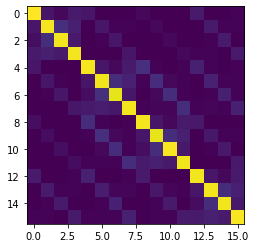

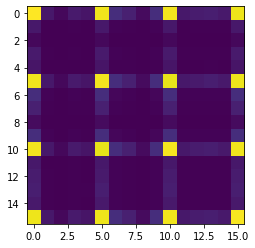

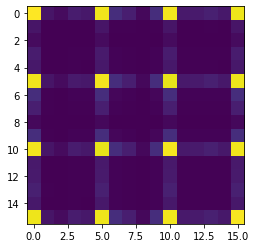

In [10]:
# testing Choi matrix

Umat = mkLiouvillian(0.1, 0.1, ldbldOp=S_Z)

plt.imshow(abs(Umat.round(2)))
X = np.reshape(np.transpose(np.reshape(Umat,[4,4,4,4]),[0,2,1,3]),[16,16])
plt.figure()
plt.imshow(abs(X))

# Idk why the following is different
T=np.zeros([16,16])
T=np.array(T,dtype='complex128')

Tprime=np.zeros([16,16])
Tprime=np.array(T,dtype='complex128')

for j in range(4):
    for i in range(4):
        # print([i for i in range(i*4,(i+1)*4)])
        Sij = np.reshape(Umat[i*4:(i+1)*4,j*4:(j+1)*4],[1,16]).T
        ei = np.zeros(4)
        ei[i] = 1
        ej = np.zeros(4)
        ej[j] = 1  
        Eij = np.reshape(np.outer(ei,ej),[1,16])
                         
        T += np.outer(Sij, Eij)
        
        # method 2
        ei = np.zeros(4)
        ei[i] = 1
        ej = np.zeros(4)
        ej[j] = 1  
        Eij = np.outer(ei,ej)

        Tprime += np.kron(Eij, np.eye(4)) @ Umat @ np.kron(np.eye(4), Eij)
          
        
     
plt.figure()
plt.imshow(abs(T))
plt.imshow(abs(Tprime))

print(np.allclose(T,X))


[eigVals, eigVecs] = linalg.eig(T)

M=[]
for i in range(16):
    # dividing by the laregst eigenvalue or something?
    M = M + [np.reshape(eigVecs[:,i],[4,4])]

Ktotal=np.zeros([4,4],dtype='complex128')
for x in M:
    Ktotal += x.T.conj()@x

    
abs(Ktotal).round(10)
eigVals

In [63]:
def partialTranspose(densityM,i):
    out = np.copy(densityM)
    N=int(np.log2((densityM).shape[1]))
    if i>N:
        print('Not enough number of parties to be transposed')
    else:
        for t in range(2**i):
            j=2**i-1-t
            out[2**N-2**(N-i-1)*(2*j+1):2**N-j*2**(N-i),2*j*2**(N-i-1):(2*j+1)*2**(N-i-1)]\
                =densityM[2*t*2**(N-i-1):(2*t+1)*2**(N-i-1),2**N-2**(N-i-1)*(2*t+1):2**N-t*2**(N-i)]
            out[2*t*2**(N-i-1):(2*t+1)*2**(N-i-1),2**N-2**(N-i-1)*(2*t+1):2**N-t*2**(N-i)]\
                =densityM[2**N-2**(N-i-1)*(2*j+1):2**N-j*2**(N-i),2*j*2**(N-i-1):(2*j+1)*2**(N-i-1)]
            
    return out

In [42]:
def calcS(densityM, Ntot,partiesToTraceOut=[1]):
    redRho = partial_trace(densityM, partiesToTraceOut, [2]* Ntot)
    eVals = np.linalg.eigvalsh(redRho)
    eVals = eVals[np.where(eVals>1e-12)]
    S = -sum(eVals*np.log2(eVals))
    return S

def calcPurity(densityM):
    purity = np.trace(densityM@densityM)
    return purity
    

In [ ]:
steps=10
ent=np.zeros(steps)
pur=np.zeros(steps)

vec=mkLindbladU(0.4)@np.reshape(initState,[16,1])
vec.reshape([4,4])
for i in range(steps):
    vec=mkLindbladU(0.1)@vec # this is a vector that is reshaped, not the state itself
    reshapedDensity
    ent[i]=calcS(mkDensityMat(vec),4,[1])
    pur[i]=np.real(calcPurity(mkDensityMat(vec)))
    
